In [1]:
# /// script
# requires-python = ">=3.10"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
#     "pandas",
#     "seaborn",
#     "bobiac_tools @ git+https://github.com/bobiac/bobiac-tools.git"
# ]
# ///

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import skimage
import tifffile
from bobiac_tools import overlay_labels, ripleys_l
from scipy.spatial import KDTree

In [3]:
path_image = "../../../_static/images/quant/05_spatial_stats/images/F01_202.tif"
path_mask = "../../../_static/images/quant/05_spatial_stats/masks/F01_202w1.TIF"
path_spots = "../../../_static/images/quant/05_spatial_stats/spots/F01_202_spots.csv"

image = tifffile.imread(path_image)
mask = tifffile.imread(path_mask)
df_spots = pd.read_csv(path_spots)

mask = skimage.segmentation.clear_border(mask)

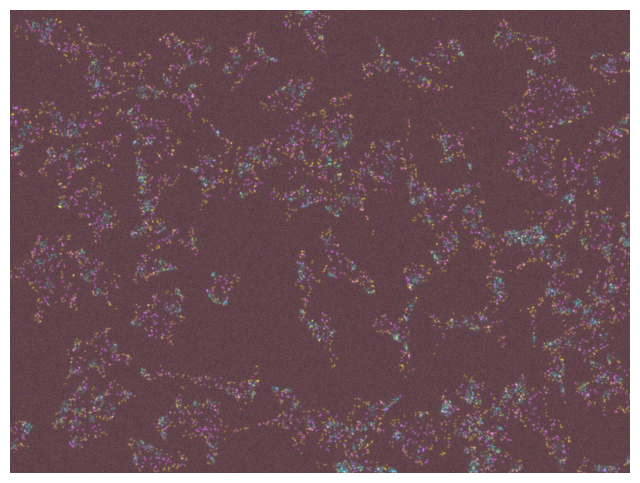

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [4]:
overlay_labels(image[2:, :, :])

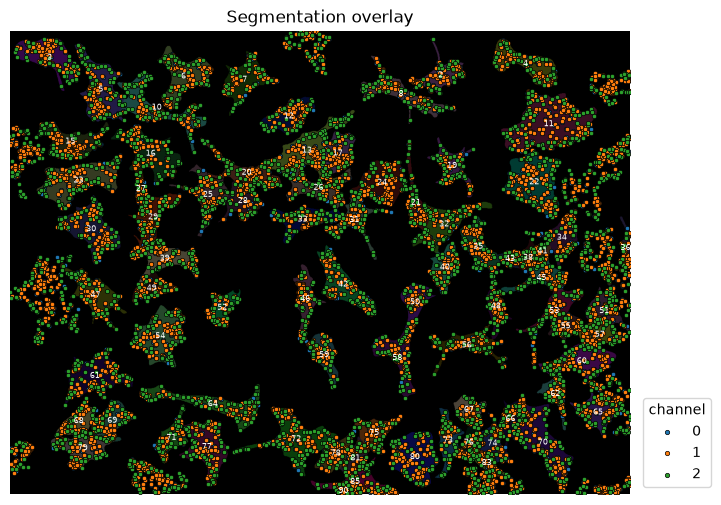

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [5]:
overlay_labels(label_mask=mask, coordinates=df_spots)

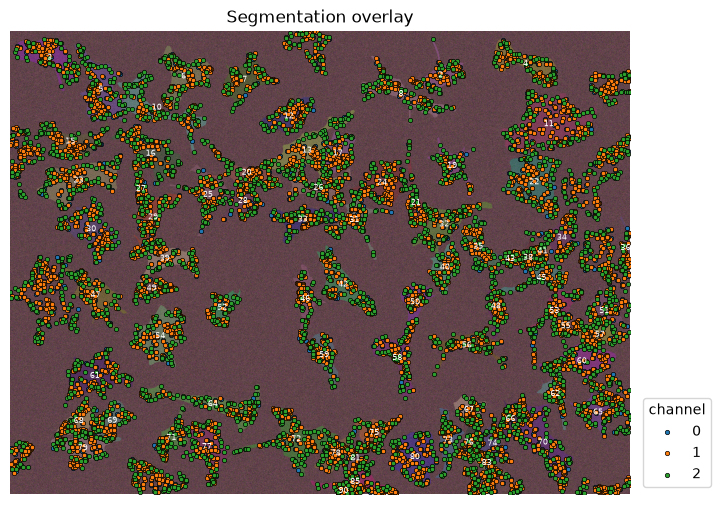

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [6]:
overlay_labels(
    image=image[2:, :, :], label_mask=mask, coordinates=df_spots, focus_object=63
)

In [7]:
df_cell = pd.DataFrame(
    skimage.measure.regionprops_table(mask, properties=["area", "label"])
)
print(df_cell)

      area  label
0   4669.0      2
1   7866.0      3
2   6945.0      4
3   9735.0      5
4   7749.0      6
..     ...    ...
72  9504.0     80
73  2878.0     81
74  1881.0     83
75  4198.0     85
76   441.0     90

[77 rows x 2 columns]


In [8]:
# map the cell label to the spots
df_spots["label_cell"] = mask[df_spots["y"].astype(int), df_spots["x"].astype(int)]
# delete spots in the background
df_spots = df_spots.loc[df_spots["label_cell"] != 0]
# count number of spots per cell label
mapping_spots = (
    df_spots.loc[df_spots["channel"] == 0]["label_cell"].value_counts().reset_index()
)
# add the cell count to the cell dataframe
df_cell = df_cell.merge(
    mapping_spots, left_on="label", right_on="label_cell", how="inner"
).drop(columns="label_cell")
print(df_spots)
print(df_cell)

       channel     y    x  label_cell
28           0   119  984           2
29           0    72  990           2
30           0   122  950           2
31           0   114  912           2
32           0    92  960           2
...        ...   ...  ...         ...
12607        2  1029  764          85
12670        2  1031  732          90
12671        2  1038  755          90
12672        2  1035  736          90
12673        2  1038  768          90

[10813 rows x 4 columns]
      area  label  count
0   4669.0      2     23
1   7866.0      3     39
2   6945.0      4     34
3   9735.0      5     48
4   7749.0      6     38
..     ...    ...    ...
72  9504.0     80     47
73  2878.0     81     14
74  1881.0     83      9
75  4198.0     85     20
76   441.0     90      2

[77 rows x 3 columns]


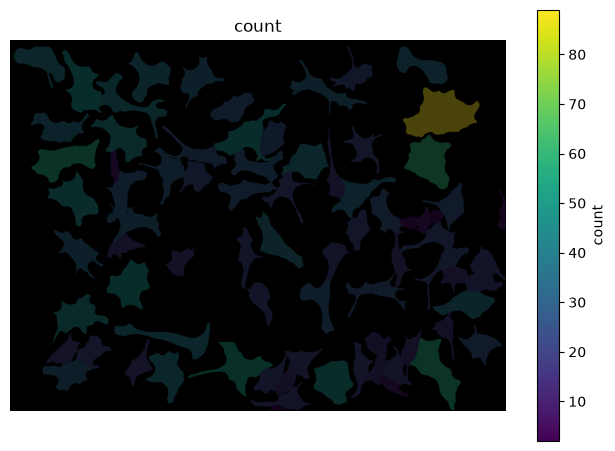

(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'count'}>)

In [9]:
overlay_labels(label_mask=mask, df=df_cell, id_col="label", measurement_col="count")

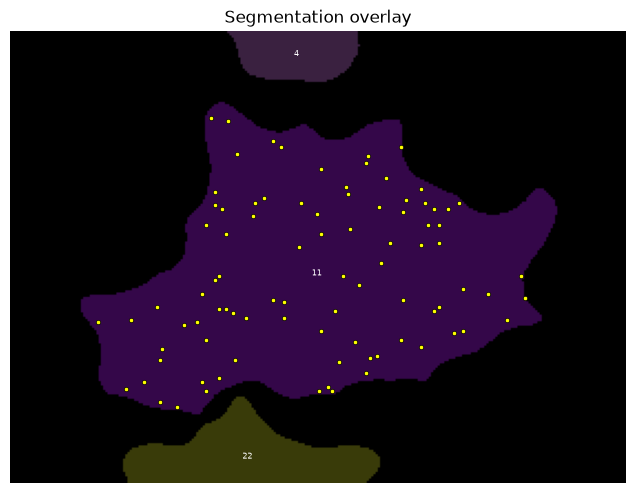

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [10]:
cell_id = 11
spots = df_spots.loc[(df_spots["channel"] == 0) & (df_spots["label_cell"] == cell_id)][
    ["y", "x"]
].to_numpy()

overlay_labels(label_mask=mask, coordinates=spots, focus_object=cell_id)

In [11]:
# or use:
# from bobiac_tools import random_points_in_mask


def random_points_in_mask(mask: np.ndarray, cell_label: int, n: int) -> np.ndarray:
    """
    Generate n random points uniformly distributed within a labeled cell region.

    Points are placed continuously using rejection sampling:
    candidate points are drawn uniformly from the bounding box of the cell and
    accepted only if they fall within the cell mask. This correctly handles
    irregular cell shapes and serves as a null model for Complete Spatial
    Randomness (CSR).

    Parameters
    ----------
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID
        and background is 0.
    cell_label : int
        ID of the cell to sample within.
    n : int
        Number of random points to generate.

    Returns
    -------
    points : (n, 2) numpy array
        Random point coordinates in (row, col) / (y, x) order.
    """
    ys, xs = np.where(mask == cell_label)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()
    points = []
    while len(points) < n:
        y = np.random.uniform(y_min, y_max)
        x = np.random.uniform(x_min, x_max)
        if mask[int(round(y)), int(round(x))] == cell_label:
            points.append([y, x])
    return np.array(points)

In [12]:
n_points = df_cell.loc[df_cell["label"] == cell_id]["count"].values[0]
print(n_points)

89


In [13]:
rnd_points = random_points_in_mask(mask, cell_label=cell_id, n=n_points)
rnd_points.shape

(89, 2)

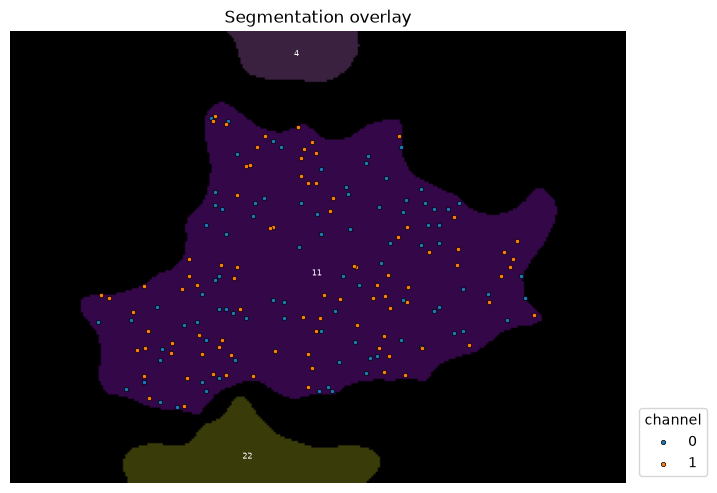

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [14]:
overlay_labels(label_mask=mask, coordinates=[spots, rnd_points], focus_object=cell_id)

In [15]:
# the query below returns an array of distances and an array of indices. We don't need the indicis so we assign it to the variable `_`.
dist_spots, _ = KDTree(spots).query(spots, k=2)
print(dist_spots)

[[ 0.         11.40175425]
 [ 0.          5.09901951]
 [ 0.          8.24621125]
 [ 0.          9.8488578 ]
 [ 0.          6.        ]
 [ 0.          8.06225775]
 [ 0.          5.83095189]
 [ 0.          6.32455532]
 [ 0.          4.47213595]
 [ 0.         13.41640786]
 [ 0.          3.16227766]
 [ 0.          9.89949494]
 [ 0.         10.81665383]
 [ 0.         14.86606875]
 [ 0.          6.08276253]
 [ 0.          7.        ]
 [ 0.          8.60232527]
 [ 0.          5.09901951]
 [ 0.          2.82842712]
 [ 0.          9.8488578 ]
 [ 0.          8.94427191]
 [ 0.          3.16227766]
 [ 0.          9.48683298]
 [ 0.         13.15294644]
 [ 0.         10.19803903]
 [ 0.         15.5241747 ]
 [ 0.         11.18033989]
 [ 0.          8.24621125]
 [ 0.          9.8488578 ]
 [ 0.         11.40175425]
 [ 0.          7.28010989]
 [ 0.          6.08276253]
 [ 0.          8.24621125]
 [ 0.         10.19803903]
 [ 0.          4.47213595]
 [ 0.          3.60555128]
 [ 0.          3.16227766]
 

In [16]:
# the query below returns an array of distances and an array of indices. We don't need the indicis so we assign it to the variable `_`.
dist_rnd, _ = KDTree(rnd_points).query(rnd_points, k=2)
print(dist_rnd)

[[ 0.          7.58375007]
 [ 0.          7.51444025]
 [ 0.          5.46539317]
 [ 0.          4.44426812]
 [ 0.          3.95007682]
 [ 0.          5.04051509]
 [ 0.         12.85178584]
 [ 0.          5.46539317]
 [ 0.         38.2893459 ]
 [ 0.          5.87427849]
 [ 0.          7.68525218]
 [ 0.          4.96584377]
 [ 0.          5.58648416]
 [ 0.          5.87427849]
 [ 0.          7.07728298]
 [ 0.          6.76721058]
 [ 0.          5.57023495]
 [ 0.          8.51824679]
 [ 0.          1.48002027]
 [ 0.          3.95007682]
 [ 0.         10.02372439]
 [ 0.          3.80861511]
 [ 0.          4.65501927]
 [ 0.          4.89411638]
 [ 0.          1.3033204 ]
 [ 0.          6.49144589]
 [ 0.         14.15598874]
 [ 0.          3.74282736]
 [ 0.          5.57023495]
 [ 0.          9.52156343]
 [ 0.          1.59261741]
 [ 0.          6.05428187]
 [ 0.          4.14488423]
 [ 0.          9.87484208]
 [ 0.         21.48087996]
 [ 0.          5.94908018]
 [ 0.          3.74282736]
 

In [17]:
spot_dist_avg = dist_spots[:, 1].mean()
rnd_dist_avg = dist_rnd[:, 1].mean()
print("Mean NN distance spots:", spot_dist_avg)
print("Mean NN distance random:", rnd_dist_avg)
print("Clark-Evans index (ratio):", spot_dist_avg / rnd_dist_avg)

Mean NN distance spots: 7.382794742295512
Mean NN distance random: 7.396919620418393
Clark-Evans index (ratio): 0.9980904377973919


In [18]:
n_repeats = 10

list_rnd_dist = []  # this list holds the average NN distances of the random points for each run

for _i in range(n_repeats):
    rnd_points = random_points_in_mask(mask, cell_label=cell_id, n=n_points)
    dist_rnd, _ = KDTree(rnd_points).query(rnd_points, k=2)
    rnd_dist_avg = dist_rnd[:, 1].mean()
    list_rnd_dist.append(rnd_dist_avg)

rnd_dist_avg = np.array(list_rnd_dist).mean()
clark_evans = spot_dist_avg / rnd_dist_avg

print("Mean NN distance spots:", spot_dist_avg)
print(f"Mean NN distance random ({n_repeats} runs):", rnd_dist_avg)
print(f"Clark-Evans index ({n_repeats} runs):", clark_evans)

Mean NN distance spots: 7.382794742295512
Mean NN distance random (10 runs): 7.551103415323377
Clark-Evans index (10 runs): 0.9777107180539578


In [19]:
runs_rnd_smaller = np.array(list_rnd_dist) <= spot_dist_avg
print(runs_rnd_smaller)

[False False False False False  True  True  True False False]


In [20]:
pval = runs_rnd_smaller.mean()
print("p-value for CE index:", pval)

p-value for CE index: 0.3


In [21]:
# or use:
# from bobiac_tools import nn_dist


def nn_dist(
    spots: np.ndarray, mask: np.ndarray, cell_id: int, n_repeats: int
) -> tuple[float, float, float, float]:
    """
    Test whether spots in a cell are randomly distributed using nearest-neighbor
    distances and a Monte Carlo simulation of Complete Spatial Randomness (CSR).

    For each simulation run, n_repeats random point patterns are generated inside
    the cell mask and their mean nearest-neighbor distance is computed. The
    Clark-Evans index (observed / random NND) and a Monte Carlo p-value are
    derived from this null distribution.

    Parameters
    ----------
    spots : (n, 2) numpy array
        Spot coordinates in (row, col) / (y, x) order.
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID.
    cell_id : int
        ID of the cell in mask that spots belong to.
    n_repeats : int
        Number of CSR simulations to run.

    Returns
    -------
    spot_dist_avg : float
        Mean nearest-neighbor distance of the observed spots.
    rnd_dist_avg : float
        Mean of the per-simulation mean nearest-neighbor distances under CSR.
    clark_evans : float
        Clark-Evans index: spot_dist_avg / rnd_dist_avg.
        < 1 indicates clustering, > 1 indicates dispersion.
    p_value : float
        Fraction of CSR simulations with mean NND <= spot_dist_avg.
        Small values (< 0.05) indicate significant clustering.
    """
    n_points = spots.shape[0]

    dist_spots, _ = KDTree(spots).query(spots, k=2)
    spot_dist_avg = dist_spots[
        :, 1
    ].mean()  # k=2: column 0 is self, column 1 is nearest neighbor

    list_rnd_dist = []
    for _i in range(n_repeats):
        rnd_points = random_points_in_mask(mask, cell_label=cell_id, n=n_points)
        dist_rnd, _ = KDTree(rnd_points).query(rnd_points, k=2)
        rnd_dist_avg = dist_rnd[:, 1].mean()
        list_rnd_dist.append(rnd_dist_avg)

    rnd_dist_avg = np.array(list_rnd_dist).mean()
    clark_evans = spot_dist_avg / rnd_dist_avg
    pval = (np.array(list_rnd_dist) <= spot_dist_avg).mean()

    return (
        spot_dist_avg,
        rnd_dist_avg,
        clark_evans,
        pval,
    )


nn_dist(spots, mask, cell_id, 100)

(np.float64(7.382794742295512),
 np.float64(7.50128551459793),
 np.float64(0.9842039378354779),
 np.float64(0.42))

In [22]:
channel = 0
n_repeats = 10

results = []
for _, row in df_cell.iterrows():
    # get the spots for channel 0 and the current cell
    spots_in_cell = df_spots[
        (df_spots["label_cell"] == row["label"]) & (df_spots["channel"] == channel)
    ][["y", "x"]].values
    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(nn_dist(spots_in_cell, mask, row["label"], n_repeats=n_repeats))

df_cell[["nnd_observed", "nnd_random", "clark_evans", "p_value"]] = results
df_cell

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value
0,4669.0,2,23,7.542691,8.424651,0.895312,0.3
1,7866.0,3,39,7.040435,7.905550,0.890569,0.1
2,6945.0,4,34,7.250944,7.570875,0.957742,0.2
3,9735.0,5,48,7.201960,7.660002,0.940203,0.2
4,7749.0,6,38,7.557600,7.768490,0.972853,0.2
...,...,...,...,...,...,...,...
72,9504.0,80,47,7.071116,7.751189,0.912262,0.1
73,2878.0,81,14,7.357530,9.123912,0.806401,0.1
74,1881.0,83,9,5.538022,9.109394,0.607946,0.0
75,4198.0,85,20,7.137660,8.431323,0.846565,0.1


In [23]:
df_cell.loc[df_cell["label"] == cell_id]

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value
8,17915.0,11,89,7.382795,7.442827,0.991934,0.5


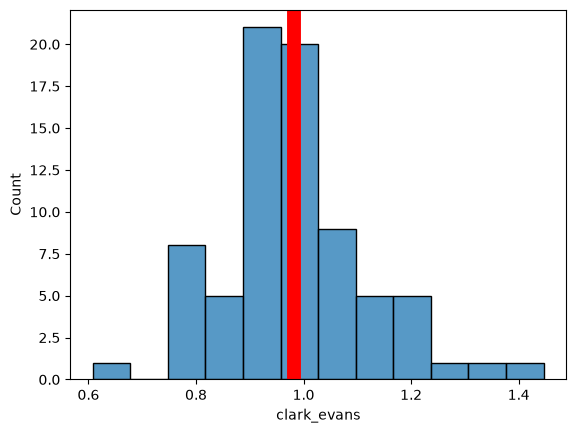

In [24]:
sns.histplot(
    df_cell,
    x="clark_evans",
)
plt.axvline(df_cell["clark_evans"].mean(), c="red", lw=10)

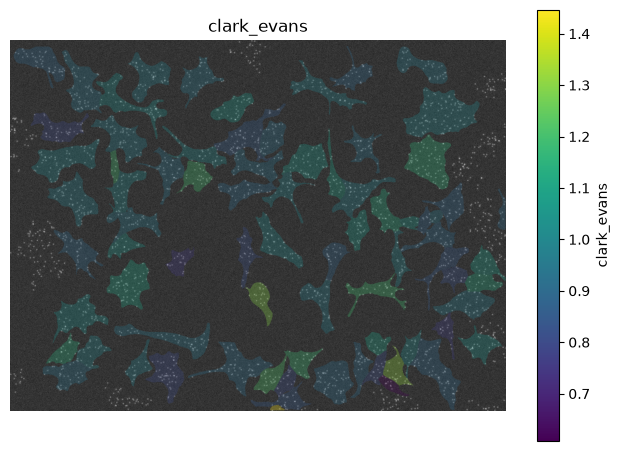

(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'clark_evans'}>)

In [25]:
overlay_labels(
    image=image[2, :, :],
    label_mask=mask,
    df=df_cell,
    id_col="label",
    measurement_col="clark_evans",
)

In [26]:
channel = 1
n_repeats = 10

results = []
for _, row in df_cell.iterrows():
    # get the spots for channel 0 and the current cell
    spots_in_cell = df_spots[
        (df_spots["label_cell"] == row["label"]) & (df_spots["channel"] == channel)
    ][["y", "x"]].values
    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(nn_dist(spots_in_cell, mask, row["label"], n_repeats=n_repeats))

df_cell[["nnd_observed", "nnd_random", "clark_evans", "p_value"]] = results
df_cell

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value
0,4669.0,2,23,3.854920,4.464964,0.863371,0.0
1,7866.0,3,39,4.270026,5.349347,0.798233,0.0
2,6945.0,4,34,4.445110,4.870329,0.912692,0.2
3,9735.0,5,48,4.891864,5.361681,0.912375,0.0
4,7749.0,6,38,4.489295,5.015529,0.895079,0.0
...,...,...,...,...,...,...,...
72,9504.0,80,47,4.367094,5.158174,0.846636,0.0
73,2878.0,81,14,3.344642,3.484418,0.959885,0.3
74,1881.0,83,9,2.414088,3.136460,0.769686,0.0
75,4198.0,85,20,3.384426,4.322734,0.782936,0.0


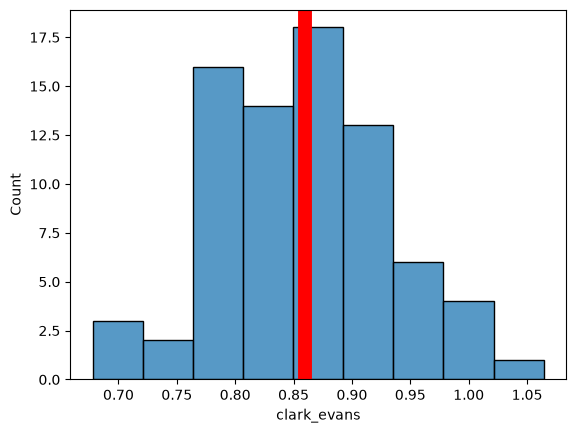

In [27]:
sns.histplot(
    df_cell,
    x="clark_evans",
)
plt.axvline(df_cell["clark_evans"].mean(), c="red", lw=10)

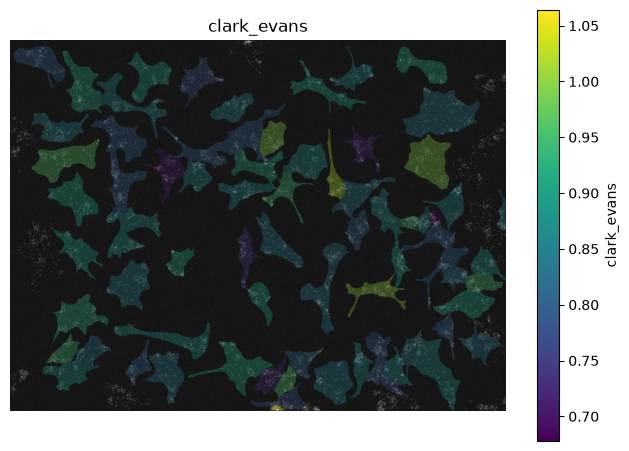

(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'clark_evans'}>)

In [28]:
overlay_labels(
    image=image[3, :, :],
    label_mask=mask,
    df=df_cell,
    id_col="label",
    measurement_col="clark_evans",
)

In [29]:
channel = 2
n_repeats = 10

results = []
for _, row in df_cell.iterrows():
    # get the spots for channel 0 and the current cell
    spots_in_cell = df_spots[
        (df_spots["label_cell"] == row["label"]) & (df_spots["channel"] == channel)
    ][["y", "x"]].values
    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(nn_dist(spots_in_cell, mask, row["label"], n_repeats=n_repeats))

df_cell[["nnd_observed", "nnd_random", "clark_evans", "p_value"]] = results
df_cell

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value
0,4669.0,2,23,6.870816,7.040617,0.975883,0.4
1,7866.0,3,39,7.355929,7.574855,0.971098,0.5
2,6945.0,4,34,6.231751,7.103239,0.877311,0.1
3,9735.0,5,48,6.240532,7.007292,0.890577,0.1
4,7749.0,6,38,6.343255,6.749658,0.939789,0.4
...,...,...,...,...,...,...,...
72,9504.0,80,47,6.363679,7.807400,0.815083,0.0
73,2878.0,81,14,6.751128,6.358954,1.061673,0.7
74,1881.0,83,9,7.651594,6.130065,1.248208,0.9
75,4198.0,85,20,6.427021,6.672263,0.963245,0.5


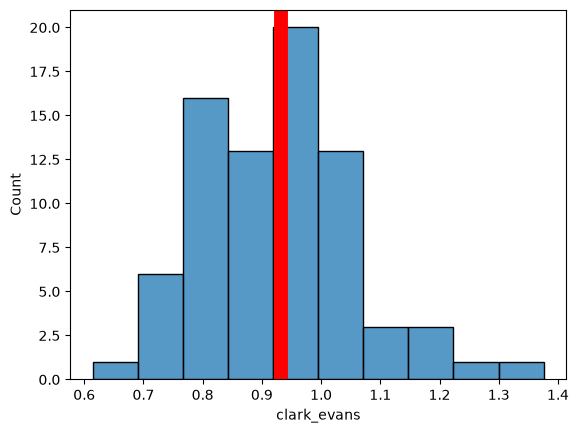

In [30]:
sns.histplot(
    df_cell,
    x="clark_evans",
)
plt.axvline(df_cell["clark_evans"].mean(), c="red", lw=10)

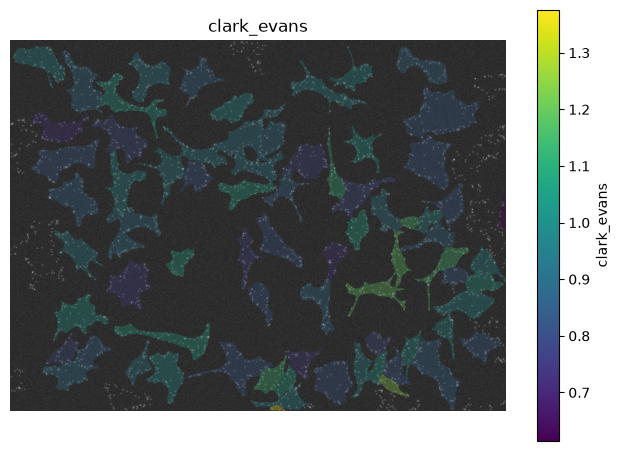

(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'clark_evans'}>)

In [31]:
overlay_labels(
    image=image[4, :, :],
    label_mask=mask,
    df=df_cell,
    id_col="label",
    measurement_col="clark_evans",
)

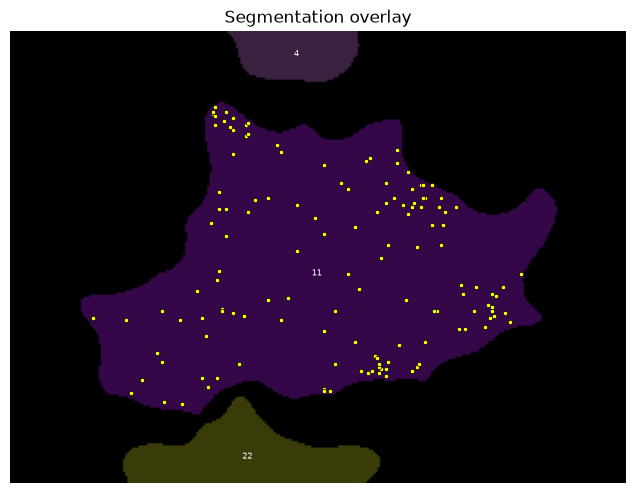

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [32]:
spots = df_spots.loc[(df_spots["channel"] == 1) & (df_spots["label_cell"] == cell_id)][
    ["y", "x"]
].to_numpy()
overlay_labels(label_mask=mask, coordinates=spots, focus_object=cell_id)

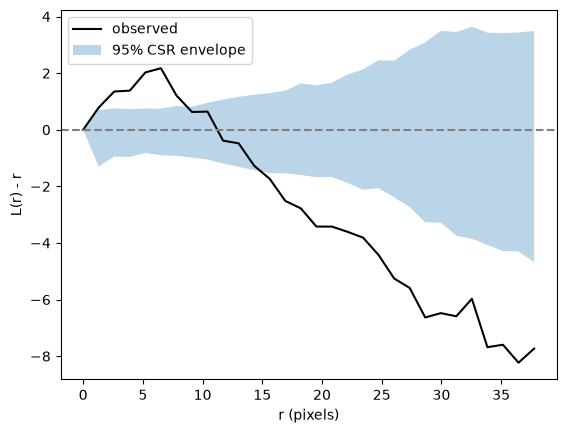

In [33]:
r_values, L_obs, L_sims = ripleys_l(spots, mask, cell_id=cell_id, n_repeats=200)

plt.plot(r_values, L_obs, color="black", label="observed")
plt.fill_between(
    r_values,
    np.percentile(L_sims, 2.5, axis=0),
    np.percentile(L_sims, 97.5, axis=0),
    alpha=0.3,
    label="95% CSR envelope",
)

plt.axhline(0, color="grey", linestyle="--")
plt.xlabel("r (pixels)")
plt.ylabel("L(r) - r")
plt.legend()